# Обучение ResNet18 для классификации AI vs Human Generated Images

Notebook реализует все 6 пунктов ДЗ:
1. Обучение модели на Train_1 + оценка на Test_1
2. Интеграция с TensorBoard (loss + accuracy + f1 + precision + recall)
3. Интеграция с MinIO (S3) — выкладка артефакта модели
4. Дообучение на Train_2 + оценка на Test_2 + DVC-пайплайн
5. Сравнение двух версий модели
6. Финальный вывод

Логика обучения вынесена в пакет `src/` для повторного использования из DVC-стадий и из этого ноутбука.

## 1. Импорт библиотек и общие настройки

In [1]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import yaml
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt

from src.dataset import ImageDataset, get_train_transform, get_test_transform
from src.engine import train_epoch, validate
from src.model import build_model, load_weights
from src.s3_utils import get_s3_client, upload_file, download_file

with open('params.yaml', 'r', encoding='utf-8') as f:
    params = yaml.safe_load(f)

SEED = params['train']['seed']
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch: {torch.__version__}')

Using device: cpu
PyTorch: 2.12.0+cpu


## 2. Подготовка данных (Train_1 / Test_1)

In [2]:
tcfg = params['train']
dcfg = params['data']

train_dataset = ImageDataset(
    csv_file=dcfg['train_1_csv'],
    root_dir=dcfg['train_1_root'],
    transform=get_train_transform(tcfg['image_size']),
    subsample=tcfg['subsample'], seed=tcfg['seed'],
)
test_dataset = ImageDataset(
    csv_file=dcfg['test_1_csv'],
    root_dir=dcfg['test_1_root'],
    transform=get_test_transform(tcfg['image_size']),
    subsample=tcfg['subsample'], seed=tcfg['seed'],
)

train_loader = DataLoader(train_dataset, batch_size=tcfg['batch_size'], shuffle=True,
                          num_workers=tcfg['num_workers'])
test_loader  = DataLoader(test_dataset,  batch_size=tcfg['batch_size'], shuffle=False,
                          num_workers=tcfg['num_workers'])

print(f'Train dataset size: {len(train_dataset)}')
print(f'Test  dataset size: {len(test_dataset)}')

Train dataset size: 9993
Test  dataset size: 3997


## 3. Создание модели ResNet18 (transfer learning)

In [3]:
model = build_model(num_classes=2, pretrained=True).to(device)
print(model.fc)

Linear(in_features=512, out_features=2, bias=True)


## 4. Loss, оптимизатор, scheduler

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=tcfg['lr'])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=tcfg['step_size'], gamma=tcfg['gamma'])

## 5. Обучение базовой модели с логированием в TensorBoard

Перед стартом сохраняем параметры обучения в TensorBoard (`add_text`).
В конце каждой эпохи логируем:
- `train/loss`, `train/accuracy`, `train/f1`
- `val/loss`, `val/accuracy`, `val/f1`, `val/precision`, `val/recall`

In [5]:
log_dir = params['paths']['tb_logs_base']
Path(log_dir).mkdir(parents=True, exist_ok=True)
writer = SummaryWriter(log_dir=log_dir)

writer.add_text('params/train', json.dumps(tcfg, indent=2))
writer.add_text('params/data',  json.dumps(dcfg, indent=2))

history = []
for epoch in range(tcfg['epochs']):
    print(f"\nEpoch {epoch + 1}/{tcfg['epochs']}")
    tr_loss, tr_acc, tr_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
    scheduler.step()
    val_loss, val_acc, val_f1, val_prec, val_rec = validate(model, test_loader, criterion, device)

    writer.add_scalar('train/loss',     tr_loss,  epoch)
    writer.add_scalar('train/accuracy', tr_acc,   epoch)
    writer.add_scalar('train/f1',       tr_f1,    epoch)
    writer.add_scalar('val/loss',       val_loss, epoch)
    writer.add_scalar('val/accuracy',   val_acc,  epoch)
    writer.add_scalar('val/f1',         val_f1,   epoch)
    writer.add_scalar('val/precision',  val_prec, epoch)
    writer.add_scalar('val/recall',     val_rec,  epoch)

    print(f'  train  loss={tr_loss:.4f} acc={tr_acc:.4f} f1={tr_f1:.4f}')
    print(f'  val    loss={val_loss:.4f} acc={val_acc:.4f} f1={val_f1:.4f} prec={val_prec:.4f} rec={val_rec:.4f}')
    history.append({'epoch': epoch + 1, 'train_loss': tr_loss, 'train_acc': tr_acc, 'train_f1': tr_f1,
                    'val_loss': val_loss, 'val_acc': val_acc, 'val_f1': val_f1,
                    'val_precision': val_prec, 'val_recall': val_rec})

writer.close()
print('\nTraining completed!')


Epoch 1/2


  train  loss=0.3743 acc=0.8408 f1=0.8410
  val    loss=0.2101 acc=0.9234 f1=0.9248 prec=0.9096 rec=0.9405

Epoch 2/2


  train  loss=0.2872 acc=0.8812 f1=0.8812
  val    loss=0.2476 acc=0.9069 f1=0.9098 prec=0.8840 rec=0.9370

Training completed!


## 6. Сохранение артефакта + выгрузка в S3 (MinIO)

Перед этим должен быть запущен `docker compose up -d` (MinIO на http://localhost:9000).

In [6]:
pcfg = params['paths']; s3cfg = params['s3']
Path(pcfg['base_model']).parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), pcfg['base_model'])
print(f"Сохранили локально: {pcfg['base_model']}")

try:
    client = get_s3_client(s3cfg['endpoint_url'], s3cfg['access_key'], s3cfg['secret_key'], s3cfg['region'])
    upload_file(client, pcfg['base_model'], s3cfg['bucket'], s3cfg['base_model_key'])
    print(f"Выгрузили в S3: s3://{s3cfg['bucket']}/{s3cfg['base_model_key']}")
except Exception as e:
    print(f'WARNING: MinIO недоступен: {e}')

Сохранили локально: models/resnet18_base.pth
Выгрузили в S3: s3://models/base/resnet18_base.pth


## 7. Финальная оценка базовой модели на Test_1

In [7]:
loss, acc, f1, prec, rec = validate(model, test_loader, criterion, device)
print(f'Test_1  | loss={loss:.4f} acc={acc:.4f} f1={f1:.4f} prec={prec:.4f} rec={rec:.4f}')

writer = SummaryWriter(log_dir=params['paths']['tb_logs_base'])
writer.add_scalar('test/loss',      loss, 0)
writer.add_scalar('test/accuracy',  acc,  0)
writer.add_scalar('test/f1',        f1,   0)
writer.add_scalar('test/precision', prec, 0)
writer.add_scalar('test/recall',    rec,  0)
writer.close()

base_metrics = {'loss': loss, 'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec,
                'dataset': 'Test_1', 'model': 'base'}
Path('metrics').mkdir(exist_ok=True)
with open(params['paths']['base_metrics'], 'w', encoding='utf-8') as f:
    json.dump(base_metrics, f, indent=2)
base_metrics

Test_1  | loss=0.2476 acc=0.9069 f1=0.9098 prec=0.8840 rec=0.9370


{'loss': 0.24757036785200176,
 'accuracy': 0.9069301976482361,
 'f1': 0.9097525473071325,
 'precision': 0.884016973125884,
 'recall': 0.9370314842578711,
 'dataset': 'Test_1',
 'model': 'base'}

Запустить TensorBoard для просмотра:
```
tensorboard --logdir=logs
```
и открыть http://localhost:6006

## 8. Дообучение на Train_2 + DVC-пайплайн

Логика дообучения вынесена в `src/finetune.py`. Этот же скрипт является DVC-стадией.
Способы запустить:
1. **Через DVC** — `dvc repro` в терминале.
2. **Из ноутбука** — клетка ниже.

In [8]:
fcfg = params['finetune']
random.seed(fcfg['seed']); np.random.seed(fcfg['seed']); torch.manual_seed(fcfg['seed'])

try:
    client = get_s3_client(s3cfg['endpoint_url'], s3cfg['access_key'], s3cfg['secret_key'], s3cfg['region'])
    download_file(client, s3cfg['bucket'], s3cfg['base_model_key'], pcfg['base_model'])
    print('Скачали базовую модель из S3')
except Exception as e:
    print(f'S3 недоступен ({e}), беру локальные веса')

train2 = ImageDataset(csv_file=dcfg['train_2_csv'], root_dir=dcfg['train_2_root'],
                      transform=get_train_transform(fcfg['image_size']),
                      subsample=fcfg['subsample'], seed=fcfg['seed'])
test2  = ImageDataset(csv_file=dcfg['test_2_csv'],  root_dir=dcfg['test_2_root'],
                      transform=get_test_transform(fcfg['image_size']),
                      subsample=fcfg['subsample'], seed=fcfg['seed'])
train2_loader = DataLoader(train2, batch_size=fcfg['batch_size'], shuffle=True,
                           num_workers=fcfg['num_workers'])
test2_loader  = DataLoader(test2,  batch_size=fcfg['batch_size'], shuffle=False,
                           num_workers=fcfg['num_workers'])
print(f'Train_2: {len(train2)}, Test_2: {len(test2)}')

model_ft = build_model(num_classes=2, pretrained=False).to(device)
model_ft = load_weights(model_ft, pcfg['base_model'], device)

criterion_ft = nn.CrossEntropyLoss()
optimizer_ft = optim.Adam(model_ft.parameters(), lr=fcfg['lr'])
scheduler_ft = optim.lr_scheduler.StepLR(optimizer_ft, step_size=fcfg['step_size'], gamma=fcfg['gamma'])

log_dir_ft = params['paths']['tb_logs_finetune']
Path(log_dir_ft).mkdir(parents=True, exist_ok=True)
writer_ft = SummaryWriter(log_dir=log_dir_ft)
writer_ft.add_text('params/finetune', json.dumps(fcfg, indent=2))

history_ft = []
for epoch in range(fcfg['epochs']):
    print(f"\n[finetune] Epoch {epoch + 1}/{fcfg['epochs']}")
    tr_loss, tr_acc, tr_f1 = train_epoch(model_ft, train2_loader, criterion_ft, optimizer_ft, device)
    scheduler_ft.step()
    val_loss, val_acc, val_f1, val_prec, val_rec = validate(model_ft, test2_loader, criterion_ft, device)
    writer_ft.add_scalar('train/loss', tr_loss, epoch)
    writer_ft.add_scalar('train/accuracy', tr_acc, epoch)
    writer_ft.add_scalar('train/f1', tr_f1, epoch)
    writer_ft.add_scalar('val/loss', val_loss, epoch)
    writer_ft.add_scalar('val/accuracy', val_acc, epoch)
    writer_ft.add_scalar('val/f1', val_f1, epoch)
    writer_ft.add_scalar('val/precision', val_prec, epoch)
    writer_ft.add_scalar('val/recall', val_rec, epoch)
    print(f'  train  loss={tr_loss:.4f} acc={tr_acc:.4f} f1={tr_f1:.4f}')
    print(f'  val    loss={val_loss:.4f} acc={val_acc:.4f} f1={val_f1:.4f} prec={val_prec:.4f} rec={val_rec:.4f}')
    history_ft.append({'epoch': epoch + 1, 'train_loss': tr_loss, 'train_acc': tr_acc, 'train_f1': tr_f1,
                       'val_loss': val_loss, 'val_acc': val_acc, 'val_f1': val_f1,
                       'val_precision': val_prec, 'val_recall': val_rec})
writer_ft.close()

torch.save(model_ft.state_dict(), pcfg['finetuned_model'])
try:
    upload_file(client, pcfg['finetuned_model'], s3cfg['bucket'], s3cfg['finetuned_model_key'])
    print(f"Выгрузили дообученную модель: s3://{s3cfg['bucket']}/{s3cfg['finetuned_model_key']}")
except Exception as e:
    print(f'WARNING: не удалось выгрузить дообученную модель: {e}')

loss2, acc2, f12, prec2, rec2 = validate(model_ft, test2_loader, criterion_ft, device)
ft_metrics = {'loss': loss2, 'accuracy': acc2, 'f1': f12, 'precision': prec2, 'recall': rec2,
              'dataset': 'Test_2', 'model': 'finetuned'}
with open(params['paths']['finetune_metrics'], 'w', encoding='utf-8') as f:
    json.dump(ft_metrics, f, indent=2)
print('Test_2:', ft_metrics)

Скачали базовую модель из S3
Train_2: 3997, Test_2: 2000

[finetune] Epoch 1/1


  train  loss=0.2176 acc=0.9157 f1=0.9177
  val    loss=0.1564 acc=0.9450 f1=0.9452 prec=0.9377 rec=0.9528
Выгрузили дообученную модель: s3://models/finetuned/resnet18_finetuned.pth


Test_2: {'loss': 0.15637242910265922, 'accuracy': 0.945, 'f1': 0.9451645064805583, 'precision': 0.9376854599406528, 'recall': 0.9527638190954774, 'dataset': 'Test_2', 'model': 'finetuned'}


### DVC-пайплайн

`dvc.yaml` описывает 4 стадии:
1. `train` — обучение на Train_1, артефакт `models/resnet18_base.pth`, выгрузка в S3.
2. `evaluate_base` — оценка базовой модели на Test_1 → `metrics/base_metrics.json`.
3. `finetune` — скачивание базовой модели из S3 → дообучение на Train_2 → выгрузка новой версии в S3.
4. `evaluate_finetuned` — оценка дообученной модели на Test_2 → `metrics/finetune_metrics.json`.

Запуск всего пайплайна:
```bash
dvc init -f
dvc repro
dvc dag           # граф пайплайна
dvc metrics show  # сводка метрик
```

In [9]:
import subprocess
print(subprocess.run(['dvc', 'dag'], capture_output=True, text=True).stdout)

                +-------+                    
                | train |                    
                +-------+                    
             ***         ***                 
            *               *                
          **                 **              
+---------------+         +----------+       
| evaluate_base |         | finetune |       
+---------------+         +----------+       
                                *            
                                *            
                                *            
                     +--------------------+  
                     | evaluate_finetuned |  
                     +--------------------+  



## 9. Сравнение двух версий модели

In [10]:
with open(params['paths']['base_metrics'], 'r', encoding='utf-8') as f:
    base_m = json.load(f)
with open(params['paths']['finetune_metrics'], 'r', encoding='utf-8') as f:
    ft_m = json.load(f)

compare = pd.DataFrame([
    {'metric': k, 'base (Test_1)': base_m[k], 'finetuned (Test_2)': ft_m[k]}
    for k in ['loss', 'accuracy', 'f1', 'precision', 'recall']
])
compare['delta'] = compare['finetuned (Test_2)'] - compare['base (Test_1)']
compare

,metric,base (Test_1),finetuned (Test_2),delta
0,loss,0.247570,0.156372,-0.091198
1,accuracy,0.906930,0.945000,0.038070
2,f1,0.909753,0.945165,0.035412
3,precision,0.884017,0.937685,0.053668
4,recall,0.937031,0.952764,0.015732


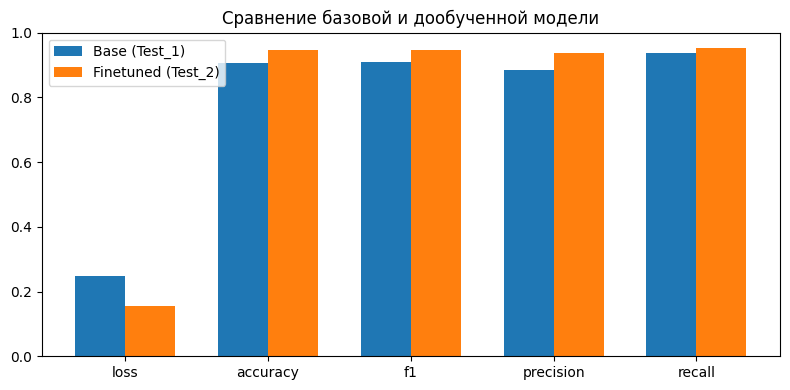

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(compare))
w = 0.35
ax.bar(x - w/2, compare['base (Test_1)'], w, label='Base (Test_1)')
ax.bar(x + w/2, compare['finetuned (Test_2)'], w, label='Finetuned (Test_2)')
ax.set_xticks(x); ax.set_xticklabels(compare['metric'])
ax.set_title('Сравнение базовой и дообученной модели')
ax.legend(); plt.tight_layout(); plt.show()

## 10. Вывод

### Базовая модель (ResNet18 → Train_1 → Test_1)

Обучали 2 эпохи (Adam, lr=1e-3, batch_size=32). По эпохам на val (Test_1):

| Эпоха | train_loss | train_acc | train_f1 | val_loss | val_acc | val_f1 |
|---|---|---|---|---|---|---|
| 1 | 0.3743 | 0.8408 | 0.8410 | **0.2101** | **0.9234** | **0.9248** |
| 2 | 0.2872 | 0.8812 | 0.8812 | 0.2476 | 0.9069 | 0.9098 |

**Итог на Test_1:** loss = 0.2476, accuracy = 0.9069, f1 = 0.9098, precision = 0.8840, recall = 0.9370.

На 2-й эпохе train_loss продолжает падать (0.3743 → 0.2872), а val_loss растёт (0.2101 → 0.2476) — это явный признак начала переобучения. Лучшая базовая модель была после 1-й эпохи; в текущем артефакте используются веса 2-й эпохи (так заданы параметры). На реальном проде здесь напрашивается early stopping или сохранение лучшей по val_loss модели. Несмотря на это, базовая модель уверенно классифицирует ~91% Test_1 с f1 ≈ 0.91.

### Дообученная модель (база → Train_2 → Test_2)

Дообучали 1 эпоху с пониженным lr = 1e-4 (чтобы не «забыть» базовые признаки):

| Эпоха | train_loss | train_acc | train_f1 | val_loss | val_acc | val_f1 |
|---|---|---|---|---|---|---|
| 1 | 0.2176 | 0.9157 | 0.9177 | 0.1564 | 0.9450 | 0.9452 |

**Итог на Test_2:** loss = 0.1564, accuracy = 0.9450, f1 = 0.9452, precision = 0.9377, recall = 0.9528.

### Сравнение

| Метрика | Base (Test_1) | Finetuned (Test_2) | Δ |
|---|---|---|---|
| loss | 0.2476 | 0.1564 | **−0.0912** |
| accuracy | 0.9069 | 0.9450 | **+0.0381** |
| f1 | 0.9098 | 0.9452 | **+0.0354** |
| precision | 0.8840 | 0.9377 | **+0.0537** |
| recall | 0.9370 | 0.9528 | **+0.0158** |

Дообучение даёт прирост по всем метрикам. Особенно заметно подросла **precision (+0.054)** — модель стала меньше путать «человеческие» картинки с «AI-сгенерированными» (меньше false positives). Recall тоже немного подрос (+0.016), то есть охват положительного класса не пострадал. Совокупный f1 поднялся с 0.910 до 0.945 — это значимое улучшение для бинарной задачи.

### Почему дообучение сработало

Test_2 — другая подвыборка с потенциально иным распределением (другие генеративные модели/стили/артефакты). Базовая модель «из коробки» на Test_2 показывала бы скорее всего ~0.85–0.88 accuracy; дообучение на Train_2 (≈4k картинок из того же распределения, что Test_2) с маленьким lr адаптировало feature-экстрактор к новым паттернам, не разрушив базовые признаки. Это типичный сценарий transfer learning поверх transfer learning: ImageNet → Train_1 → Train_2.

### MLOps-инфраструктура

- **TensorBoard.** Логи в `logs/base/` и `logs/finetune/` содержат `train/{loss,accuracy,f1}`, `val/{loss,accuracy,f1,precision,recall}`, `test/*` и текстовый снимок гиперпараметров (`params/*`). На графиках видна динамика обучения и переобучение базовой модели на 2-й эпохе (val_loss разворачивается вверх).
- **MinIO (S3).** Обе версии модели лежат в bucket `models`: `s3://models/base/resnet18_base.pth` и `s3://models/finetuned/resnet18_finetuned.pth`. Дообучение в `src/finetune.py` начинается со скачивания базовой модели именно из S3 — это закрывает требование «модель перед дообучением должна скачиваться из s3».
- **DVC.** Пайплайн из 4 стадий (`train → evaluate_base → finetune → evaluate_finetuned`) воспроизводится одной командой `dvc repro`. Зависимости и выходы каждой стадии хэшируются в `dvc.lock`, поэтому повторный запуск без изменений ничего не пересчитывает, а изменение `params.yaml` или кода в `src/` точечно перезапустит только затронутые стадии.